In [193]:
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier,VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
X,Y = make_moons(n_samples=500,noise = 0.30,random_state=42)
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,random_state=42)

In [194]:
voting_clf = VotingClassifier(
    estimators=[
        ('lr',LogisticRegression(random_state=42)),
        ('rf',RandomForestClassifier(random_state=42)),
        ('svc',SVC(random_state=42,probability=True))
    ]
    ,voting = 'soft'
)

voting_clf.fit(X_train,Y_train)

VotingClassifier(estimators=[('lr', LogisticRegression(random_state=42)),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('svc', SVC(probability=True, random_state=42))],
                 voting='soft')

In [195]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(DecisionTreeClassifier(),n_estimators=75,n_jobs=-1,random_state=42,oob_score=True)
bag_clf.fit(X_train,Y_train)
dec_tree = DecisionTreeClassifier(random_state=42)
dec_tree.fit(X_train,Y_train)

DecisionTreeClassifier(random_state=42)

Great follow-up! Let’s break it down **visually** so you can **see** where the grid is and how it's created by `np.meshgrid()`.

---

## 👨‍🏫 Starting Point:

```python
import numpy as np

x = np.array([1, 2, 3])
y = np.array([10, 20])

X, Y = np.meshgrid(x, y)
```

### ✨ What we gave:

* `x = [1, 2, 3]` → x-axis values
* `y = [10, 20]` → y-axis values

---

## 🔲 What `meshgrid` does:

It creates all possible **(x, y)** coordinate pairs in a **grid** structure.

### 1️⃣ Coordinate Pairs Created:

```
(x=1, y=10)   (x=2, y=10)   (x=3, y=10)
(x=1, y=20)   (x=2, y=20)   (x=3, y=20)
```

Each of these is a **point on a 2D grid**.

---

### 2️⃣ X and Y Arrays Returned:

```python
X =
[[1 2 3]
 [1 2 3]]

Y =
[[10 10 10]
 [20 20 20]]
```

* `X[i][j]` contains the x-coordinate of the point at row `i`, column `j`
* `Y[i][j]` contains the y-coordinate of the same point

So for example:

* `X[1][2] = 3`, `Y[1][2] = 20` → This point is (3, 20)

---

## 🎨 Visual Grid (Conceptual):

Here’s a **2D grid visualization** of `(X[i][j], Y[i][j])`:

|        | x=1    | x=2    | x=3    |
| ------ | ------ | ------ | ------ |
| y=10 → | (1,10) | (2,10) | (3,10) |
| y=20 → | (1,20) | (2,20) | (3,20) |

That’s your meshgrid — every combination of `x` and `y` values arranged like a 2D grid.

---

## 📌 Why is this useful?

You can now evaluate any function at every point on the grid. For example:

```python
Z = X + Y
```

Would produce:

```
[[11 12 13]
 [21 22 23]]
```

Because:

* `Z[0][0] = 1 + 10 = 11`
* `Z[1][2] = 3 + 20 = 23`

---

## ✅ Summary

* `np.meshgrid()` does **not** create a visual grid on its own.
* It returns **2 arrays** (X and Y), which **together define the grid** of coordinates.
* You use these arrays to evaluate functions, plot surfaces, or draw decision boundaries.

---

Want to see it drawn with `matplotlib`?


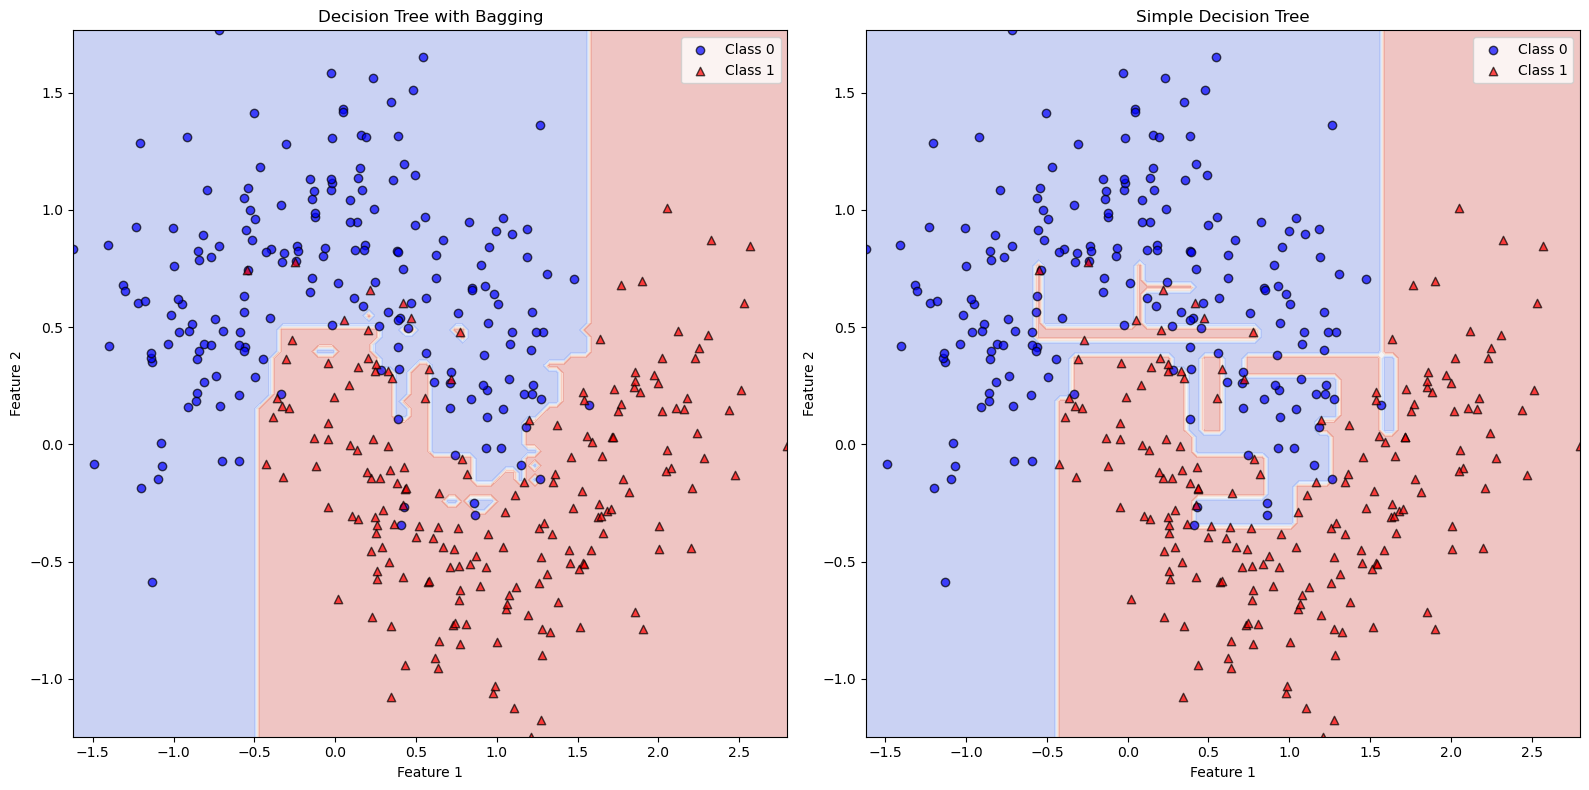

In [196]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(model, X_train, Y_train, feature_names=("Feature 1", "Feature 2"), title="Decision Boundary",self_plot = True):
    # Create meshgrid
    x_min, x_max = X_train[:, 0].min(), X_train[:, 0].max()
    y_min, y_max = X_train[:, 1].min(), X_train[:, 1].max()
    X1 = np.linspace(x_min, x_max, num=100)
    X2 = np.linspace(y_min, y_max, num=100)
    X_grid, Y_grid = np.meshgrid(X1, X2)
    grid = np.c_[X_grid.ravel(), Y_grid.ravel()]
    
    # Predict on mesh
    Z = model.predict(grid).reshape(X_grid.shape)
    
    # Plot decision surface
    plt.contourf(X_grid, Y_grid, Z, alpha=0.3, cmap='coolwarm')
    
    # Class separation
    class_0 = Y_train == 0
    class_1 = Y_train == 1
    
    # Plot data points
    plt.scatter(X_train[class_0, 0], X_train[class_0, 1],
                color='blue', edgecolor='k', marker='o', label='Class 0', alpha=0.7)
    plt.scatter(X_train[class_1, 0], X_train[class_1, 1],
                color='red', edgecolor='k', marker='^', label='Class 1', alpha=0.7)
    
    # Labels and legend
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title(title)
    plt.legend()
    if self_plot:
        plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

plt.sca(axes[0]) 
plot_decision_boundary(bag_clf, X_train, Y_train, title="Decision Tree with Bagging",self_plot=False)
plt.sca(axes[1]) 
plot_decision_boundary(dec_tree, X_train, Y_train, title="Simple Decision Tree",self_plot=False)
plt.tight_layout()
plt.show()

In [197]:
bag_clf.oob_score_

0.8933333333333333

In [198]:
y_pred = bag_clf.predict(X_test)

In [199]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,y_pred)

0.888

In [200]:
bag_clf.oob_decision_function_[:3]

array([[0.44117647, 0.55882353],
       [0.22222222, 0.77777778],
       [1.        , 0.        ]])

In [201]:
from sklearn.ensemble import RandomForestClassifier
rnd_clf = RandomForestClassifier(n_estimators=500,max_leaf_nodes = 16,n_jobs= -1, random_state=42)
rnd_clf.fit(X_train,Y_train)
y_pred_rf = rnd_clf.predict(X_test)

In [202]:
rnd_clf.feature_importances_

array([0.42253629, 0.57746371])

In [203]:
from sklearn.ensemble import AdaBoostClassifier

abc_clf = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1),n_estimators=50,learning_rate= 0.5,random_state=42)
abc_clf.fit(X_train,Y_train)

c:\Users\jitik\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.5, random_state=42)

In [204]:
abc_clf.score(X_test,Y_test)

0.888

In [205]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)
X = np.random.rand(100,1) - 0.5
Y = 3 * X[:,0] ** 2 + 0.05 * np.random.randn(100)

In [206]:
tree_reg_1 = DecisionTreeRegressor(max_depth=2,random_state=42)
tree_reg_1.fit(X,Y)

DecisionTreeRegressor(max_depth=2, random_state=42)

In [207]:
y2 = Y - tree_reg_1.predict(X)
tree_reg_2 = DecisionTreeRegressor(max_depth=2,random_state=43)
tree_reg_2.fit(X,y2)

DecisionTreeRegressor(max_depth=2, random_state=43)

In [208]:
y3 = y2 - tree_reg_2.predict(X)
tree_reg_3 = DecisionTreeRegressor(max_depth=2,random_state=44)
tree_reg_3.fit(X,y3)

DecisionTreeRegressor(max_depth=2, random_state=44)

In [209]:
X_new = np.array([[-0.4],[0],[-11],[0.5]])
sum(tree.predict(X_new) for tree in (tree_reg_1,tree_reg_2,tree_reg_3))

array([0.49484029, 0.04021166, 0.6679558 , 0.75026781])

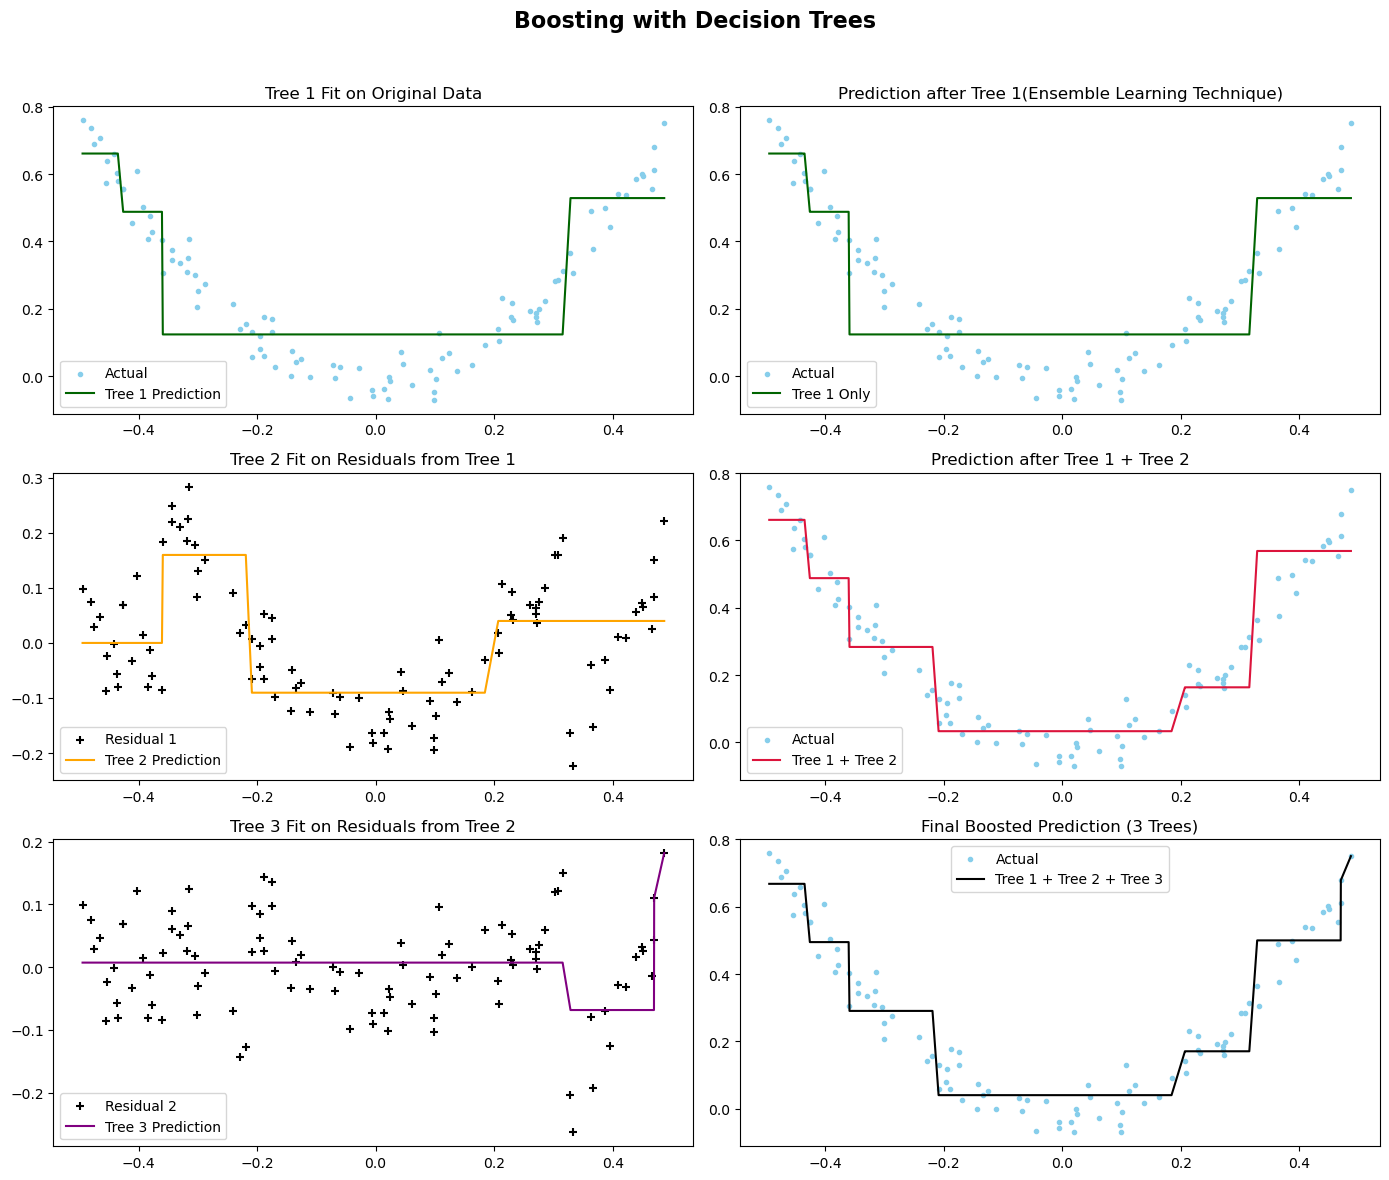

In [210]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle("Boosting with Decision Trees", fontsize=16, weight='bold')

X_sorted = np.sort(X, axis=0)

axes[0][0].scatter(X, Y, color='skyblue', marker='.', label="Actual")
Y_pred_sorted_1 = tree_reg_1.predict(X_sorted)
axes[0][0].plot(X_sorted, Y_pred_sorted_1, color='darkgreen', label="Tree 1 Prediction")
axes[0][0].set_title("Tree 1 Fit on Original Data")
axes[0][0].legend()

axes[1][0].scatter(X, y2, color='black', marker='+', label="Residual 1")
Y_pred_sorted_2 = tree_reg_2.predict(X_sorted)
axes[1][0].plot(X_sorted, Y_pred_sorted_2, color='orange', label="Tree 2 Prediction")
axes[1][0].set_title("Tree 2 Fit on Residuals from Tree 1")
axes[1][0].legend()

axes[2][0].scatter(X, y3, color='black', marker='+', label="Residual 2")
Y_pred_sorted_3 = tree_reg_3.predict(X_sorted)
axes[2][0].plot(X_sorted, Y_pred_sorted_3, color='purple', label="Tree 3 Prediction")
axes[2][0].set_title("Tree 3 Fit on Residuals from Tree 2")
axes[2][0].legend()

axes[0][1].scatter(X, Y, color='skyblue', marker='.', label="Actual")
axes[0][1].plot(X_sorted, Y_pred_sorted_1, color='darkgreen', label="Tree 1 Only")
axes[0][1].set_title("Prediction after Tree 1(Ensemble Learning Technique)")
axes[0][1].legend()

axes[1][1].scatter(X, Y, color='skyblue', marker='.', label="Actual")
combined_pred_2 = Y_pred_sorted_1 + Y_pred_sorted_2
axes[1][1].plot(X_sorted, combined_pred_2, color='crimson', label="Tree 1 + Tree 2")
axes[1][1].set_title("Prediction after Tree 1 + Tree 2")
axes[1][1].legend()

axes[2][1].scatter(X, Y, color='skyblue', marker='.', label="Actual",alpha = 1)
combined_pred_3 = combined_pred_2 + Y_pred_sorted_3
axes[2][1].plot(X_sorted, combined_pred_3, color='black', label="Tree 1 + Tree 2 + Tree 3")
axes[2][1].set_title("Final Boosted Prediction (3 Trees)")
axes[2][1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [211]:
from sklearn.ensemble import GradientBoostingRegressor

gbrt_1 = GradientBoostingRegressor(max_depth=2,n_estimators=3,learning_rate=1.0,random_state=42)
gbrt_2 = GradientBoostingRegressor(max_depth=2,n_estimators=92,learning_rate=1.0,random_state=42)
gbrt_3 = GradientBoostingRegressor(max_depth=2,n_estimators=92,learning_rate=0.05,random_state=42)
gbrt_4 = GradientBoostingRegressor(max_depth=2,n_estimators = 3,learning_rate=0.05,random_state=42)

gbrt_1.fit(X,Y)
gbrt_2.fit(X,Y)
gbrt_3.fit(X,Y)
gbrt_4.fit(X,Y)

GradientBoostingRegressor(learning_rate=0.05, max_depth=2, n_estimators=3,
                          random_state=42)

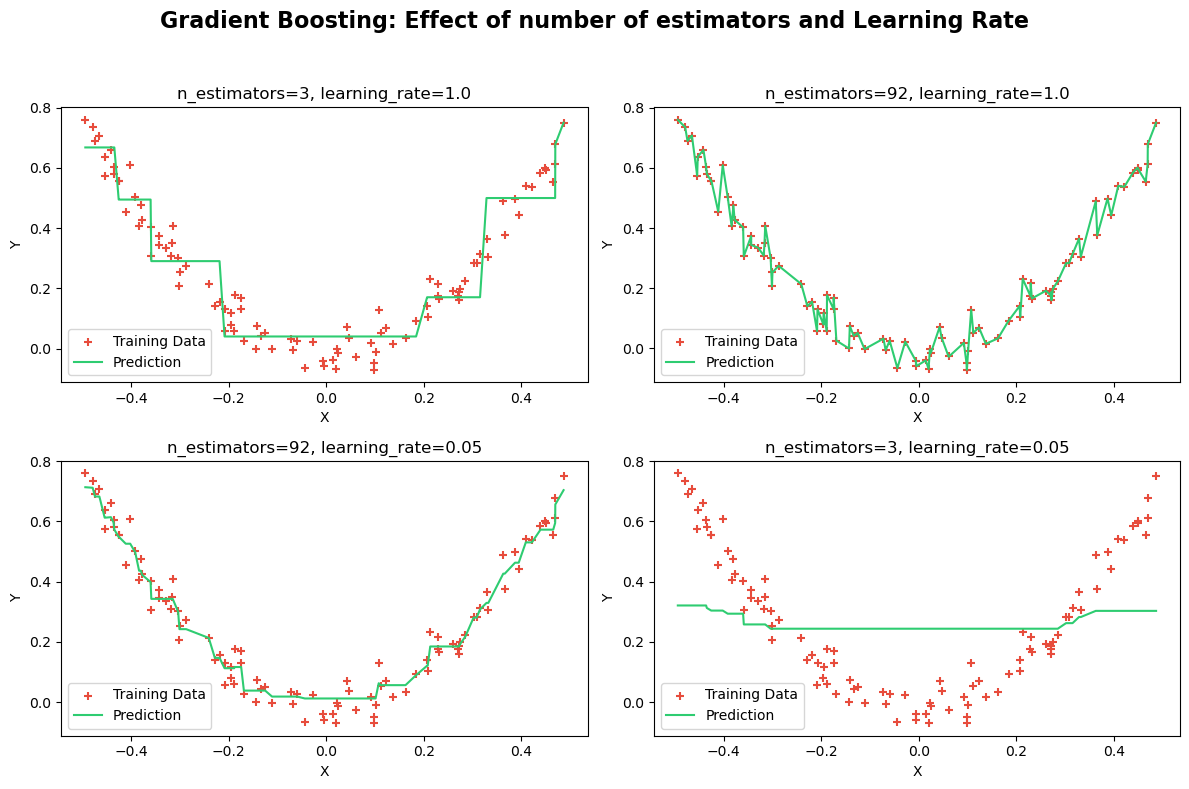

In [212]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Gradient Boosting: Effect of number of estimators and Learning Rate", fontsize=16, weight='bold')

X_sorted = np.sort(X, axis=0)

axes[0][0].scatter(X, Y, color='#e74c3c', marker='+', label="Training Data")
axes[0][0].plot(X_sorted, gbrt_1.predict(X_sorted), color='#2ecc71', label="Prediction")
axes[0][0].set_title("n_estimators=3, learning_rate=1.0")
axes[0][0].set_xlabel("X")
axes[0][0].set_ylabel("Y")
axes[0][0].legend()

axes[0][1].scatter(X, Y, color='#e74c3c', marker='+', label="Training Data")
axes[0][1].plot(X_sorted, gbrt_2.predict(X_sorted), color='#2ecc71', label="Prediction")
axes[0][1].set_title("n_estimators=92, learning_rate=1.0")
axes[0][1].set_xlabel("X")
axes[0][1].set_ylabel("Y")
axes[0][1].legend()

axes[1][0].scatter(X, Y, color='#e74c3c', marker='+', label="Training Data")
axes[1][0].plot(X_sorted, gbrt_3.predict(X_sorted), color='#2ecc71', label="Prediction")
axes[1][0].set_title("n_estimators=92, learning_rate=0.05")
axes[1][0].set_xlabel("X")
axes[1][0].set_ylabel("Y")
axes[1][0].legend()

axes[1][1].scatter(X, Y, color='#e74c3c', marker='+', label="Training Data")
axes[1][1].plot(X_sorted, gbrt_4.predict(X_sorted), color='#2ecc71', label="Prediction")
axes[1][1].set_title("n_estimators=3, learning_rate=0.05")
axes[1][1].set_xlabel("X")
axes[1][1].set_ylabel("Y")
axes[1][1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [213]:
gbrt_best = GradientBoostingRegressor(max_depth=2,n_estimators=500,n_iter_no_change=10,random_state=42)
gbrt_best.fit(X,Y)

GradientBoostingRegressor(max_depth=2, n_estimators=500, n_iter_no_change=10,
                          random_state=42)

In [214]:
gbrt_best.n_estimators_

57

In [215]:
gbrt_best.learning_rate

0.1

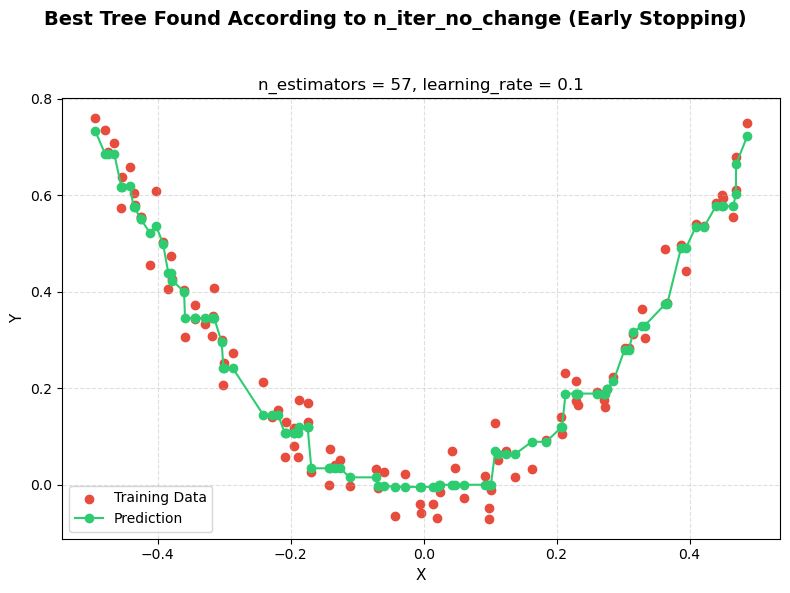

In [216]:
plt.figure(figsize=(8, 6))

plt.scatter(X, Y, color='#e74c3c', marker='o', label="Training Data")

plt.plot(X_sorted, gbrt_best.predict(X_sorted), color='#2ecc71', label="Prediction",marker = 'o',linewidth = 1.5)

plt.title("n_estimators = 57, learning_rate = 0.1", fontsize=12)
plt.suptitle("Best Tree Found According to n_iter_no_change (Early Stopping)", fontsize=14, weight='bold')

plt.xlabel("X", fontsize=11)
plt.ylabel("Y", fontsize=11)

plt.legend()
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

In [217]:
X_train

array([[ 1.53869929e+00,  1.88744130e-01],
       [ 3.94698536e-01,  3.23723608e-01],
       [-9.19146564e-01,  1.31188165e+00],
       [ 1.05396355e+00, -7.00407873e-01],
       [ 1.04067847e+00, -4.37338701e-01],
       [ 1.00933981e-01, -3.03530559e-01],
       [ 1.18128413e+00,  7.61136745e-02],
       [-1.21046915e-01, -9.08388899e-02],
       [-8.87106610e-01,  5.12633178e-01],
       [ 9.37451497e-01,  2.34296809e-01],
       [ 7.11654204e-01,  1.54701440e-01],
       [ 1.25893422e+00, -3.54797752e-01],
       [ 3.86380017e-01,  4.15946340e-01],
       [ 9.44441260e-01,  5.17911799e-01],
       [-7.40742091e-01,  5.36229504e-01],
       [ 2.05623856e+00, -2.39382466e-02],
       [ 1.85814503e+00,  3.09624394e-01],
       [-5.61395675e-01,  6.35114044e-01],
       [ 1.19704521e+00,  1.05274369e-01],
       [-8.14968012e-01,  2.64231623e-01],
       [ 2.15881305e+00,  1.49840044e-01],
       [ 1.11201360e+00, -2.15523587e-01],
       [ 1.30882068e+00,  7.26225254e-01],
       [-7.

In [218]:
from sklearn.ensemble import StackingClassifier

stacking_clf = StackingClassifier(
    estimators=[
        ('lr',LogisticRegression(random_state=42)),
        ('rf',RandomForestClassifier(random_state=42)),
        ('svc',SVC(random_state=42))
    ],
    final_estimator=RandomForestClassifier(random_state=43),
    cv = 5
)
stacking_clf.fit(X_train,Y_train)

StackingClassifier(cv=5,
                   estimators=[('lr', LogisticRegression(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('svc', SVC(random_state=42))],
                   final_estimator=RandomForestClassifier(random_state=43))

In [219]:
voting_clf.score(X_test,Y_test) # Hard-Voting Classifier

0.92

In [220]:
stacking_clf.score(X_test,Y_test) # Trains a blender on the predictions

0.92

## Exercise solutions chapter 7 

1. Yes , we can train diffferent models on the same exact data , we can use ensemble learning , i.e. we make the models vote for the best in terms of classification and average in case of regression , as collective wisdom of the models will overshadow each model's individual shortcomings , alterantively we can use a blender too , also ensemble will work best if the data they are trained on is different , (the whole point of bagging and pasting) , not only that if the model are different in the way they function , the results would still be good.

2. Hard-voting classifiers , do a majority vote on the hard-predictions such as 0 or 1 , what the model predicted , soft-voting takes into account how confient the model was while predicting 0 or 1 , and uses weighted sum of all the other probabilities to predict the final outcome , for example if a model is confident that 0 is 90 % , 1 is 51 % , 1 is 52 % , you cant neglect the 90 % as the other two models are not that sure. 

3. Yes , bagging ensemble works great parallely and so does pasting , core reason of why they scale so well , BOOSTING Ensembles dont work parallely , because each estimator gets trained on the short-comings of the previous estimator , hence we have to wait for the predictions to come before we begin training , also random-forests can work parallely , as it can train many decision trees paralelly

4. Out-of-Bag evaluation generally happens in the concept of bagging in the training set , where random data is selected with replacement , by mathematics it can be shown that if bagging samples are equal to total samples , then on an sample on an avaerage only 67% of the original samples are collected , rest repeats . Hence those remaining 37 % can act as pseudo-validation sets, and we can use these evaluations to test evaluate a bagging ensemble, This method allows validation without requiring a seperate test or validation set.
, stacking can be done parallely as each model can train parallely , but the next layer of predictor can only work when one layer is complete , so its semi-parallel.

5. Random - forest is n number of decision trees , trained on random subsets of data with random - features , but they still work as decision trees at their core ,splitting on an optimal point (greedy !), but extra-trees(or extra random trees) they work by randomly selecting possible threshold values to do the split from , and then selecting the best one from it , saving a lot of time , as the most time-consuming task in decision trees or random forests is the splitting itself. so extra-trees classifiers is faster.

6. Possibly inrease the learning rate and the n_estimators hyper-parameters , we can even reduce the regularization hyper-parameters of the base-estimator.

7. Decrease the Learning rate and possible n_estimators , you can use also use n_iter_no_change hyper-paramter for early stopping to prevent over-fitting 

In [221]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784',as_frame=False)

In [222]:
X = mnist.data

In [223]:
Y = mnist.target

In [224]:
X_train,X_validate,X_test,Y_train,Y_validate,Y_test = X[:50000],X[50000:60000],X[60000:],Y[:50000],Y[50000:60000],Y[60000:]

In [243]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(random_state=42)
rand_forest_mnist = RandomForestClassifier(random_state=42,n_jobs=-1)
extra_trees_forest_mnist = ExtraTreesClassifier(n_estimators = 100,random_state=44,n_jobs = -1)
svm_mnist = LinearSVC(random_state=42,tol = 10,dual = True,max_iter = 200,verbose = 1)

rand_forest_mnist.fit(X_train,Y_train)
extra_trees_forest_mnist.fit(X_train,Y_train)
svm_mnist.fit(X_train,Y_train)
hgb.fit(X_train,Y_train)

c:\Users\jitik\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


HistGradientBoostingClassifier(random_state=42)

In [244]:
hgb.score(X_test,Y_test)

0.9768

In [245]:
rand_forest_mnist.score(X_test,Y_test)

0.968

In [246]:
rand_forest_mnist.score(X_validate,Y_validate)

0.9736

In [247]:
extra_trees_forest_mnist.score(X_test,Y_test)

0.9722

In [248]:
extra_trees_forest_mnist.score(X_validate,Y_validate)

0.9755

In [249]:
svm_mnist.score(X_test,Y_test)

0.8442

In [250]:
svm_mnist.score(X_validate,Y_validate)

0.8605

In [252]:
from sklearn.ensemble import VotingClassifier

voting_clf_hard = VotingClassifier(
    [
        ('random_forest',rand_forest_mnist),
        ('extra_trees_forest',extra_trees_forest_mnist),
        ('svm_mnist',svm_mnist),
        ('hgb',hgb)
    ]
    ,voting = 'hard',
    verbose=True,
    n_jobs=-2
)

voting_clf_hard.fit(X_train,Y_train)
voting_clf_hard.score(X_test,Y_test)

0.9729

In [253]:
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC

svc_mnist = SVC(kernel = 'linear',max_iter=200,tol = 10,probability=True,verbose=True,random_state=42)
voting_clf_soft = VotingClassifier(
    [
        ('random_forest',rand_forest_mnist),
        ('extra_trees_forest',extra_trees_forest_mnist),
        ('svm_mnist',svc_mnist),
        ('hgb',hgb)
    ]
    ,voting = 'soft',
    verbose=True,
    n_jobs=-2
)
voting_clf_soft.fit(X_train,Y_train)
voting_clf_soft.score(X_test,Y_test)

0.978

In [254]:
voting_clf_soft.score(X_validate,Y_validate)

0.98

In [255]:
rand_forest_mnist_pred = rand_forest_mnist.predict(X_validate)
extra_trees_forest_mnist_pred = rand_forest_mnist.predict(X_validate)
svc_mnist_pred = svm_mnist.predict(X_validate)
hgb_mnist_pred = hgb.predict(X_validate)

In [256]:
combined_estimators_trained_set = np.array(np.c_[rand_forest_mnist_pred,extra_trees_forest_mnist_pred,svc_mnist_pred,hgb_mnist_pred])

In [257]:
combined_estimators_trained_set.shape

(10000, 4)

In [258]:
Y_validate.shape

(10000,)

In [268]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_blender = HistGradientBoostingClassifier()
log_reg_blender = LogisticRegression(
    C=1.0,              # lower = stronger regularization
    solver='saga',      # better for large and sparse data
    max_iter=1000,
    multi_class='multinomial',
    class_weight='balanced'  # optional, may not help much here
)
rand_forest_blender = RandomForestClassifier(random_state=42,oob_score=True)

log_reg_blender.fit(combined_estimators_trained_set,Y_validate)
rand_forest_blender.fit(combined_estimators_trained_set,Y_validate)
hgb_blender.fit(combined_estimators_trained_set,Y_validate)


HistGradientBoostingClassifier()

In [269]:
from sklearn.metrics import accuracy_score

rand_forest_mnist_pred_validate = rand_forest_mnist.predict(X_test)
extra_trees_forest_mnist_pred_validate = extra_trees_forest_mnist.predict(X_test)
svm_mnist_pred_validate = rand_forest_mnist.predict(X_test)
hgb_mnist_pred_validate = hgb.predict(X_test)

In [270]:
combined_estimators_pred_validate = np.c_[rand_forest_mnist_pred_validate,extra_trees_forest_mnist_pred,svm_mnist_pred_validate,hgb_mnist_pred_validate]

In [271]:
combined_estimators_pred_validate.shape

(10000, 4)

In [272]:
log_reg_blender.score(combined_estimators_pred_validate,Y_test)

0.5943

In [273]:
log_reg_blender_pred = log_reg_blender.predict(combined_estimators_pred_validate)
log_reg_blender_pred

array(['7', '3', '2', ..., '4', '5', '6'], dtype=object)

In [274]:
rand_forest_blender_pred = rand_forest_blender.predict(combined_estimators_pred_validate)
rand_forest_blender_pred

array(['7', '2', '1', ..., '4', '5', '6'], dtype=object)

In [275]:
hgb_blender.score(combined_estimators_pred_validate,Y_test)

0.9748

In [276]:
rand_forest_blender.score(combined_estimators_pred_validate,Y_test)

0.9216

In [278]:
rand_forest_blender.oob_score_

0.9762